In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform



In [30]:
Q = np.array(
    [
        [-10.0, 19.7365809, 19.7365809, 5.42015853, 5.42015853],
        [19.7365809, -10.0, 20.67626392, 0.17675796, 0.85604541],
        [19.7365809, 20.67626392, -10.0, 0.85604541, 0.17675796],
        [5.42015853, 0.17675796, 0.85604541, -10.0, 0.32306662],
        [5.42015853, 0.85604541, 0.17675796, 0.32306662, -10.0],
    ]
)

Because the QUBO is small, we can classically check all solutions and mark the optimal ones. This will help us later in the tutorial to visualize the quality of our quantum approach.

In [31]:
bitstrings = [np.binary_repr(i, len(Q)) for i in range(2 ** len(Q))]
costs = []
# this takes exponential time with the dimension of the QUBO
for b in bitstrings:
    z = np.array(list(b), dtype=int)
    cost = z.T @ Q @ z
    costs.append(cost)
zipped = zip(bitstrings, costs)
sort_zipped = sorted(zipped, key=lambda x: x[1])
print(sort_zipped[:3])

[('01011', -27.288260020000003), ('00111', -27.288260019999996), ('00101', -19.64648408)]


The two optimal solutions are 01011 and 00111, giving the lowest cost.



Let’s recall that Pulser enables you to program the Ising Hamiltonian  $$\frac{H_Q}{\hbar}(t) = \sum_{k=1}^N \left (\frac{\Omega(t)}{2} e^{-i\phi(t)} |g\rangle\langle r|_k + \frac{\Omega(t)}{2} e^{i\phi(t)} |r\rangle\langle g|_k - \delta(t) |r\rangle\langle r|_k + \sum_{j<k}\frac{C_6}{\hbar R_{kj}^6} \hat{n}_k \hat{n}_j \right)$$

The key idea is to encode the off-diagonal terms by using the Rydberg interaction between atoms:$$\left[\frac{C_6}{\hbar R_{kj}^6}\right]_{1\leq k, j \leq N}\leftrightarrow Q_{off-diagonal}$$

Since the Rydberg interaction depends on the pairwise distance between atoms k and j, this will define the Register of atoms to use in the computation.

The second idea is to find the optimal solution of the QUBO by preparing the ground-state of Q and outputing the optimal bitstrings. There are multiple approaches to prepare the ground-state of an Hamiltonian. We will here use the Quantum Adiabatic Algorithm (QAA), that is the most suited for neutral-atom quantum computers.

1. Pick a Device

   
To implement the Hamiltonian  we need a Device containing a Rydberg.Global channel. pulser.AnalogDevice and pulser.DigitalAnalogDevice are examples of Devices that contain a Rydberg.Global channel. Since the durations of the pulses will be quite long, let’s use pulser.DigitalAnalogDevice since it allows the creation of longer sequences.

We have to pick a device specific to the experiment we want to conduct when using Pulser!! (reminder from previous webinars)

In [32]:
device = pulser.DigitalAnalogDevice
device.print_specs()

----------------------------------
DigitalAnalogDevice Specifications
----------------------------------
A device with digital and analog capabilites.

Register parameters:
 - Dimensions: 2D
 - Maximum number of atoms: 100
 - Maximum distance from origin: 50 µm
 - Minimum distance between neighbouring atoms: 4 μm

Layout parameters:
 - Requires layout: Yes
 - Accepts new layout: Yes
 - Minimal number of traps: 1
 - Minimum layout filling fraction: 0.0
 - Maximum layout filling fraction: 0.5

Device parameters:
 - Rydberg level: 70
 - Ising interaction coefficient: 5420158.53
 - Channels can be reused: No
 - Supported bases: ground-rydberg, digital
 - Supported states: r, g, h
 - SLM Mask: Yes

Channels:
 - 'rydberg_global': Rydberg(addressing='Global', max_abs_detuning=125.66370614359172, max_amp=15.707963267948966, min_retarget_interval=None, fixed_retarget_t=None, max_targets=None, clock_period=4, min_duration=16, max_duration=67108864, min_avg_amp=0, mod_bandwidth=None, custom_phase

2. Create the Register

   
Let’s attempt a simple minimization procedure to find the optimal positions of the atoms in the Register that replicate best the off-diagonal terms of Q:

In [33]:
def evaluate_mapping(
    new_coords: np.ndarray, Q: np.ndarray, device: pulser.devices.Device
):
    """Cost function to minimize. Ideally, the pairwise distances are conserved."""
    new_coords = np.reshape(new_coords, (len(Q), 2))
    # computing the matrix of the distances between all coordinate pairs
    new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
    return np.linalg.norm(new_Q - Q)

In [34]:
costs = []
np.random.seed(0)
x0 = np.random.random(len(Q) * 2)
res = minimize(
    evaluate_mapping,
    x0,
    args=(Q, device),
    method="Nelder-Mead",
    tol=1e-6,
    options={"maxiter": 200000, "maxfev": None},
)
coords = np.reshape(res.x, (len(Q), 2))

We can then build the Register from the obtained coordinates:

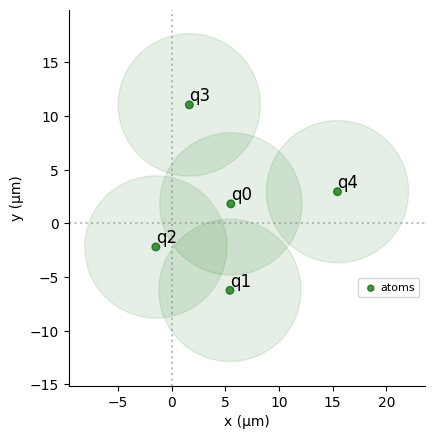

In [35]:
qubits = {f"q{i}": coord for (i, coord) in enumerate(coords)}
reg = pulser.Register(qubits)
reg.draw(
    blockade_radius=device.rydberg_blockade_radius(1.0),
    draw_graph=False,
    draw_half_radius=True,
)

In [67]:
sequence = pulser.Sequence(reg, device)

#we do this to verify this register is actually implementable on the device we chose. If not would pop an error

In this case, this simple procedure was enough to give a good and valid embedding but it will not always be so. For QUBO instances that are not as easy to embbed as this one, more complex embedding strategies are required.

The interrest of using Pulser relies here : you can chose the strategy you want or even design your own for your specific needs. In qoolqit you will be able to have some examples of these.

3. Pick the channels

   
The channel needed to implement the Ising Hamiltonian is the Rydberg.Global channel. Let’s declare this channel in the Sequence:

In [68]:
sequence.declare_channel("rydberg_global", "rydberg_global")

4. Add the Pulses

   
The idea behind the adiabatic algorithm (see Albash, Lidar, 2018(external)) is to slowly evolve the system from an easy-to-prepare groundstate to the groundstate of the Ising Hamiltonian. If done slowly enough, the system of atoms stays in the instantaneous ground-state.

In our case, we continuously vary the parameters $\Omega(t), \delta(t)$in time, starting with $\Omega(0)=0, \delta(0)<0$
 and ending with $\Omega(0)=0, \delta>0$
. The ground-state of $H(0)$
 corresponds to the initial state $|ggggg\rangle$
 and the ground-state of $H(t_f)$
 corresponds to the ground-state of the Ising Hamiltonian
.

To ensure that we are not exciting the system to states that are too excited, we keep $\Omega \in [0, \Omega_{\text{max}}]$
, and choose $\Omega_{\text{max}}$
 as the median of the values of Q to ensures that the adiabatic path is efficient.

In [69]:
# We choose a median value between the min and the max
Omega = np.median(Q[Q > 0].flatten())
delta_0 = -5  # just has to be negative
delta_f = -delta_0  # just has to be positive
T = 4000  # time in ns, we choose a time long enough to ensure the propagation of information in the system

#note here that the T, Omega and delta HAVE to fit with the constraints of the device we have chosen at the begining. 
#The units are also important: the pulser.Pulser function in next cell is for example waiting for a time T in ns and nothing else.




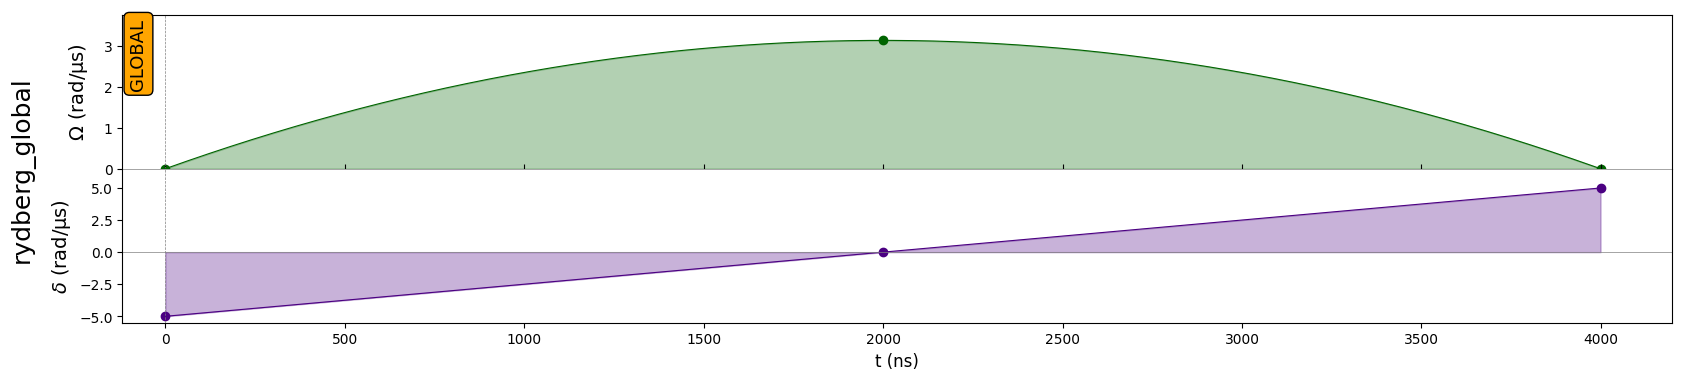

In [70]:
adiabatic_pulse = pulser.Pulse(
    pulser.InterpolatedWaveform(T, [1e-9, Omega, 1e-9]),
    pulser.InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0,
)
sequence.add(adiabatic_pulse, "rydberg_global")
sequence.draw()

In [71]:
simul = pulser_simulation.QutipBackendV2(sequence)
results = simul.run()
count_dict = results.final_bitstrings

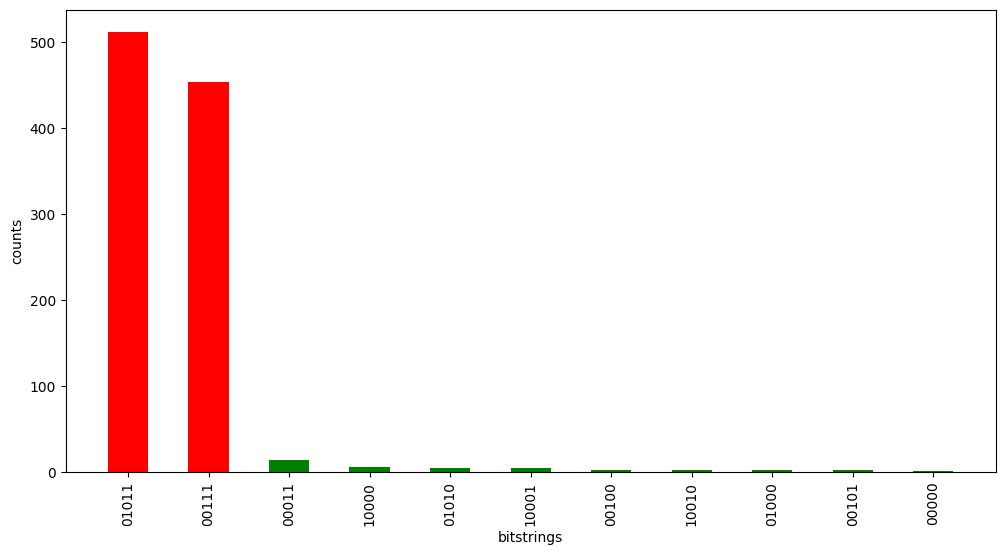

In [72]:
# Plot the distribution
# Only aestethic things here, matplotlib stuff unrelated to pulser
count_dict = dict(
    sorted(count_dict.items(), key=lambda item: item[1], reverse=True)
)
indexes = ["01011", "00111"]  # QUBO solutions
color_dict = {key: "r" if key in indexes else "g" for key in count_dict}
plt.figure(figsize=(12, 6))
plt.xlabel("bitstrings")
plt.ylabel("counts")
plt.bar(
    count_dict.keys(),
    count_dict.values(),
    width=0.5,
    color=color_dict.values(),
)
plt.xticks(rotation="vertical")
plt.show()

Let’s see how it evolves when the duration of the Sequence is increased:

In [48]:
def get_cost_colouring(bitstring, Q):
    z = np.array(list(bitstring), dtype=int)
    cost = z.T @ Q @ z
    return cost


def get_cost(counter, Q):
    cost = sum(counter[key] * get_cost_colouring(key, Q) for key in counter)
    return cost / sum(counter.values())  # Divide by total samples

In [49]:
#cell 14 done for different value of T

cost = []
for T in 1000 * np.linspace(1, 10, 10):
    seq = pulser.Sequence(reg, pulser.DigitalAnalogDevice)
    seq.declare_channel("ising", "rydberg_global")
    adiabatic_pulse = pulser.Pulse(
        pulser.InterpolatedWaveform(T, [1e-9, Omega, 1e-9]),
        pulser.InterpolatedWaveform(T, [delta_0, 0, delta_f]),
        0,
    )
    seq.add(adiabatic_pulse, "ising")
    simul = pulser_simulation.QutipBackendV2(seq)
    results = simul.run()
    count_dict = results.final_bitstrings
    cost.append(get_cost(count_dict, Q) / 3)

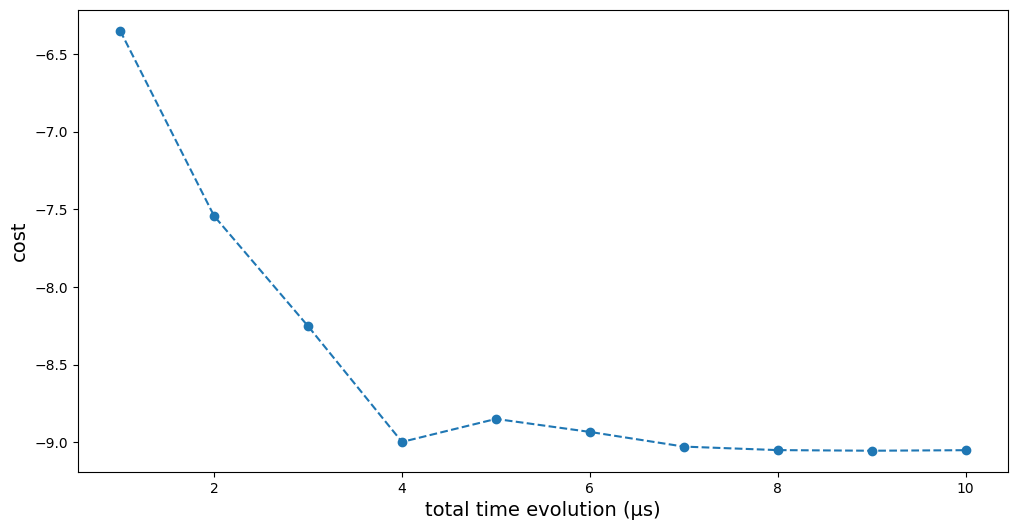

In [50]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), np.array(cost), "--o")
plt.xlabel("total time evolution (µs)", fontsize=14)
plt.ylabel("cost", fontsize=14)
plt.show()

We see why this approach is called “Adiabatic”: the quality of the solution increases (the cost decreases) if the time taken for the evolution is longer. We could see that the solution found for a shorter time are close to the 00000, meaning that the system did not have the time to evolve from its original state.

The heuristic we are using here to define the values of $\Omega$ and $\delta$ along time works well in this case. You will surely have to adapt these values if you change the matrix Q. To tune them automatically, you can use an optimization procedure to find the sequence minimizing your cost function (see get_cost function above). An example of an optimization procedure is presented in next webinar.

If the matrix Q you are trying to solve contains some odifferent diagonal elements,you need to use local addressability to solve your problem. An example of such a problem and its solution is presented in later in this session.